# Module 10 - Milestone: TinyLLM

Use this notebook after Module 09B pretraining setup and Module 10 trainer tests are passing. The focus is the first real run: prepare a corpus, train a tiny TransformerLM, track validation loss, and sample from the result. Each training section saves a rolling checkpoint to `data/`, so you can stop a run with Ctrl+C, inspect curves and samples, then re-run the cell to continue from where it left off. When a run looks done, run the **save artifact** cell at the end of its section to publish a durable model artifact under `artifacts/models/` for downstream modules.

1. Read the lesson page (`docs/modules/10-tinyllm.md`).
2. Open this notebook with `.venv/bin/python scripts/open_notebook.py 10`.
3. Answer the `Question:` / `Answer:` cells below.
4. When you're ready, ask a coding agent to grade your notebook.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [8]:
from __future__ import annotations

import math
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import g2c
from g2c.artifacts import (
    build_or_load_tokenized_corpus,
    load_or_encode_tokenized_corpus,
    load_run_state,
    resolve_corpus,
    save_model_artifact,
)
from g2c.pretraining import split_token_stream
from g2c.transformer import TransformerLM
from g2c.notebook_extras.pretraining import (
    make_encode_progress,
    make_tokenized_corpus_progress,
    plot_training_history,
    train_with_progress,
)
from g2c.notebook_extras.sampling import show_model_samples

_ = torch.manual_seed(0)
repo_root = Path(g2c.__file__).resolve().parents[1]
trainer_device = "auto"
print("MPS available:", torch.backends.mps.is_available())

MPS available: True


## Before the Notebook

Module 03B should already provide `AdamW`, `cosine_with_warmup`, and `clip_grad_norm_`. Module 09B should already provide `get_lm_batch` and `lm_cross_entropy`. For Module 10, implement `Trainer.train_step`. The trainer also depends on your completed `TransformerLM` from Module 09.

In [9]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_training.py -x"
"Then run: .venv/bin/python -m pytest tests/test_pretraining_setup.py -x"
"Then run: .venv/bin/python -m pytest tests/test_pretraining.py -x"
"Question: Which trainer test is the next one failing, and which part of train_step does it point at?"
"Answer: "

'Answer: '

In [10]:
for test_file in ["tests/test_training.py", "tests/test_pretraining_setup.py", "tests/test_pretraining.py"]:
    result = subprocess.run(
        [sys.executable, "-m", "pytest", test_file],
        cwd=repo_root,
        text=True,
        capture_output=True,
    )
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    assert result.returncode == 0, f"{test_file} is not passing yet."

print("Module 03B, Module 09B, and Module 10 tests passed.")

.....................                                                    [100%]
21 passed in 0.49s

...............                                                          [100%]
15 passed in 0.50s

............................                                             [100%]
28 passed in 1.76s

Module 03B, Module 09B, and Module 10 tests passed.


## Reset Training Checkpoints

Run this cell **on demand** to wipe the rolling training checkpoints under `data/`. The training cells below auto-resume from these checkpoints if they exist, so wipe them when you change a model or trainer config and want a fresh run. This cell does **not** touch saved model artifacts under `artifacts/models/`.

Skip this cell during normal Run All -- otherwise you will throw away in-progress training every time.

In [4]:
rolling_ckpt_pattern = "module10-*.ckpt"
removed = 0
for p in sorted((repo_root / "data").glob(rolling_ckpt_pattern)):
    p.unlink()
    print(f"removed {p.name}")
    removed += 1
if removed == 0:
    print("no rolling checkpoints found")

removed module10-tinyllm-30m.ckpt
removed module10-tinystories-30m.ckpt
removed module10-tinystories-5m.ckpt


## Exercise 1 - Prepare TinyShakespeare or Fallback Text

Use the downloaded TinyShakespeare file if setup has it. The fallback keeps the notebook runnable, but TinyShakespeare is the intended starter corpus. Keep this first run small: it proves the trainer works before you spend time on TinyStories.

In [5]:
text_max_chars = 1_000_000
shakespeare_tokenizer_name = "ShakespeareTokenizer"
# Effective vocab size for this run. None = full tokenizer vocab,
# 0 = byte + reserved special tokens only, N = truncate to merges with ID < N.
# Setting N larger than the tokenizer's trained vocab raises ValueError.
shakespeare_requested_vocab_size = None


def load_pretraining_text(max_chars: int) -> str:
    path = repo_root / "data" / "tinyshakespeare.txt"
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            return f.read(max_chars)
    base = """
    FIRST STUDENT:
    the model predicts the next token from the context.
    SECOND STUDENT:
    the context helps the model choose a better next token.
    FIRST STUDENT:
    gradients update embeddings and transformer blocks.
    """
    return ("\n".join(line.strip() for line in base.strip().splitlines()) + "\n") * 1000


text = load_pretraining_text(text_max_chars)
tokenizer, all_ids = load_or_encode_tokenized_corpus(
    text,
    shakespeare_tokenizer_name,
    label="tinyshakespeare",
    repo_root=repo_root,
    progress_callback=make_encode_progress(f"tinyshakespeare: {shakespeare_tokenizer_name}"),
    vocab_size=shakespeare_requested_vocab_size,
)
vocab_size = tokenizer.effective_vocab_size(shakespeare_requested_vocab_size)
train_ids, val_ids = split_token_stream(all_ids, train_fraction=0.9)

print("characters:", len(text))
print("tokens:", len(all_ids))
print("effective vocab size:", vocab_size)
print("tokenizer trained vocab size:", len(tokenizer.vocab))
print("uniform-loss baseline:", math.log(vocab_size))
print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))
assert len(val_ids) > 128

characters: 1000000
tokens: 264279
effective vocab size: 4096
tokenizer trained vocab size: 4096
uniform-loss baseline: 8.317766166719343
train tokens: 237851
val tokens: 26428


In [6]:
"Question: Why can a larger BPE vocabulary reduce token count but make the output logits tensor wider?"
"Answer: "
"Question: Why should validation text come from held-out token positions rather than the same windows used for training?"
"Answer: "

'Answer: '

## Exercise 2 - Train a Tiny TransformerLM

This is the first real pretraining loop now that Module 09B owns the batch and loss setup. The default below is a small payoff run rather than a smoke test: it should take longer, but the sample should move past pure token soup. If you only want to verify wiring, reduce `max_steps`, `embedding_dim`, and `num_layers` temporarily.

The training cell auto-resumes if a checkpoint exists at `data/module10-tinyshakespeare.ckpt`. Stop with Ctrl+C to inspect curves and samples, then re-run the cell to continue.

In [7]:
model_config = {
    "embedding_dim": 128,
    "num_layers": 4,
    "num_heads": 4,
    "max_seq_len": 128,
    "hidden_dim": 512,
}
trainer_config = {
    "batch_size": 32,
    "context_length": 128,
    "max_steps": 10000,
    "max_lr": 6e-4,
    "min_lr": 3e-5,
    "warmup_steps": 200,
    "weight_decay": 0.01,
    "grad_clip": 1.0,
    "eval_every": 100,
    "eval_iters": 20,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}
shakespeare_checkpoint_path = repo_root / "data" / "module10-tinyshakespeare.ckpt"

torch.manual_seed(0)
model = TransformerLM(vocab_size=vocab_size, **model_config)
history = train_with_progress(
    "TinyShakespeare",
    model,
    train_ids,
    val_ids,
    seed=0,
    checkpoint_path=shakespeare_checkpoint_path,
    checkpoint_every=100,
    checkpoint_extra={
        "model_config": model_config,
        "vocab_size": vocab_size,
        "tokenizer_artifact": shakespeare_tokenizer_name,
    },
    **trainer_config,
)

TinyShakespeare: starting fresh
TinyShakespeare params: 1,338,112
training device: mps


`[----------------------------]` `41/10,000` | tokens `167.9K` | train loss `8.186` | val loss `8.482` | val ppl `4826.8` | lr `1.23e-04` | grad norm `0.43` | elapsed `0.1 min` | tokens/s `28,698`

KeyboardInterrupt: 

### TinyShakespeare Curves and Samples

If the training cell was interrupted before its assignment completed (or you came back to a kernel that has the path but no history), the cell below reloads the model and history from the rolling checkpoint.

In [ ]:
if shakespeare_checkpoint_path.exists():
    model, history = load_run_state(shakespeare_checkpoint_path)
    last_step = history["step"][-1] if history["step"] else 0
    print(f"loaded TinyShakespeare from checkpoint at step {last_step:,}")

In [ ]:
plot_training_history(history, baseline_loss=math.log(vocab_size))

In [ ]:
"Question: Does validation loss track training loss, or is one moving much faster?"
"Answer: "
"Question: Are gradient norms largest early in training? What does clipping seem to be doing?"
"Answer: "

## Exercise 3 - Sample During or After Training

Module 11 will build the real generation utilities. For now, use a minimal local sampler so you can qualitatively inspect what pretraining learned.

Byte-level BPE can sample raw byte tokens before the model is well trained. The raw escaped sample shows that behavior directly; the readable sample uses top-k sampling and blocks control/invalid-byte tokens so the output is easier to inspect.

In [ ]:
# The quick sampler is imported in the setup cell as show_model_samples.
# It intentionally lives in notebook_extras instead of g2c.sampling.generate:
# Module 10 needs lightweight checkpoint inspection before Module 11 teaches
# and implements the full sampling stack.


In [ ]:
show_model_samples("TinyShakespeare", model, tokenizer, prompt="KING:", seed=1)

In [ ]:
"Question: How different is the raw escaped sample from the readable filtered sample?"
"Answer: "

"Question: What improved first: punctuation and line shape, local words, or global meaning?"
"Answer: "

"Question: If the readable sample is still incoherent, is that more likely a sampling issue or a training-budget/model-size issue?"
"Answer: "

### Save TinyShakespeare as `ShakespeareLM-1M`

Run **only when the run looks done.** This publishes the model under `artifacts/models/ShakespeareLM-1M/` for downstream modules. Re-running it overwrites the artifact, so don't run it on a partial run.

In [ ]:
save_model_artifact(
    "ShakespeareLM-1M",
    model=model,
    model_config=model_config,
    training_config=trainer_config,
    tokenizer_artifact_name=shakespeare_tokenizer_name,
    source=f"tinyshakespeare slice ({len(text):,} chars, {len(all_ids):,} tokens)",
    history=history,
    seed=0,
    notes="Module 10 milestone -- first real Transformer LM from scratch.",
    repo_root=repo_root,
)
print("saved ShakespeareLM-1M")

## Exercise 4 - TinyStories Scale-Up

TinyShakespeare proves the loop works, but it is too small for larger models. After running `./datasets.sh --tiny` or `./datasets.sh --small`, run the ~5M-parameter TinyStories experiment first, inspect the curves, and compare raw/readable samples. Then run the ~30M-parameter experiment and repeat the same train/curves/samples loop. Each run auto-resumes from its own rolling checkpoint, so Ctrl+C is a safe inspection point.

### TinyStories Tokenizer Prep

Run this once before the TinyStories 5M or 30M training cells. It builds or loads one disk-backed tokenized TinyStories artifact, then creates train/validation views over that same token stream. The split uses fixed 100k-token chunks with a stable seed, so validation samples come from across the corpus instead of only the tail. The raw compressed text stays in `data/`; the reusable token IDs live under `artifacts/tokenized-corpora/`.

In [ ]:
tinystories_corpus_bytes = None
tinystories_train_fraction = 0.9
tinystories_split_chunk_tokens = 100_000
tinystories_split_seed = 0
tinystories_full_spec = resolve_corpus("tinystories", repo_root=repo_root)
tinystories_sample_spec = resolve_corpus("tinystories-100MB", repo_root=repo_root)
tinystories_has_full = (
    tinystories_full_spec is not None
    and all("100MB" not in shard.path.name for source in tinystories_full_spec.sources for shard in source.shards)
)
if tinystories_has_full:
    tinystories_corpus_name = "tinystories"
    tinystories_corpus_tag = "full"
    tinystories_source_label = "full TinyStories train split"
elif tinystories_sample_spec is not None:
    tinystories_corpus_name = "tinystories-100MB"
    tinystories_corpus_tag = "100MB"
    tinystories_source_label = "100MB TinyStories sample"
else:
    tinystories_corpus_name = "tinystories"
    tinystories_corpus_tag = "full"
    tinystories_source_label = "TinyStories train split"
tinystories_tokenizer_name = "StoryTokenizer"
# See `shakespeare_requested_vocab_size` for the meaning of None / 0 / N.
tinystories_requested_vocab_size = 4096
tinystories_tokenize_workers = os.cpu_count() or 1
tinystories_tokenize_chunk_bytes = 1_000_000
vocab_tag = "full" if tinystories_requested_vocab_size is None else str(tinystories_requested_vocab_size)
tinystories_tokenized_corpus_name = f"StoryLM-tinystories-{tinystories_corpus_tag}-v{vocab_tag}"

tinystories_tokenized_corpus = None
tinystories_tokenizer = None
tinystories_train_ids = None
tinystories_val_ids = None
tinystories_vocab_size = None

try:
    tinystories_tokenized_corpus = build_or_load_tokenized_corpus(
        tinystories_tokenized_corpus_name,
        corpus=tinystories_corpus_name,
        tokenizer_name=tinystories_tokenizer_name,
        byte_count=tinystories_corpus_bytes,
        source_split="train",
        vocab_size=tinystories_requested_vocab_size,
        repo_root=repo_root,
        chunk_bytes=tinystories_tokenize_chunk_bytes,
        workers=tinystories_tokenize_workers,
        progress_callback=make_tokenized_corpus_progress("TinyStories tokenized corpus"),
    )
except FileNotFoundError as exc:
    print("Skipping TinyStories scale-up.")
    print("Run `./datasets.sh --tiny` or `./datasets.sh --small` to prepare TinyStories artifacts.")
    print(exc)
else:
    tinystories_pair = tinystories_tokenized_corpus.split(
        train_fraction=tinystories_train_fraction,
        chunk_tokens=tinystories_split_chunk_tokens,
        seed=tinystories_split_seed,
    )
    tinystories_tokenizer = tinystories_tokenized_corpus.tokenizer
    tinystories_train_ids = tinystories_pair.train
    tinystories_val_ids = tinystories_pair.val
    tinystories_vocab_size = tinystories_tokenizer.effective_vocab_size(
        tinystories_requested_vocab_size
    )
    print("TinyStories tokenized artifact:", tinystories_tokenized_corpus.artifact_dir.relative_to(repo_root))
    print("TinyStories total tokens:", len(tinystories_tokenized_corpus.tokens))
    print("TinyStories train tokens:", len(tinystories_train_ids))
    print("TinyStories valid tokens:", len(tinystories_val_ids))
    print("TinyStories effective vocab size:", tinystories_vocab_size)
    print("TinyStories tokenizer trained vocab size:", len(tinystories_tokenizer.vocab))

### TinyStories 5M Training

Auto-resumes from `data/module10-tinystories-5m.ckpt` if it exists. Re-running after Ctrl+C continues the same run.

In [ ]:
tinystories_5m_model_config = {
    "embedding_dim": 256,
    "num_layers": 6,
    "num_heads": 8,
    "max_seq_len": 256,
    "hidden_dim": 1024,
}
tinystories_5m_trainer_config = {
    "batch_size": 16,
    "context_length": 256,
    "max_steps": 30_000,
    "max_lr": 3e-4,
    "min_lr": 3e-5,
    "warmup_steps": 500,
    "weight_decay": 0.05,
    "grad_clip": 1.0,
    "eval_every": 100,
    "eval_iters": 20,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}
tinystories_5m_checkpoint_path = repo_root / "data" / "module10-tinystories-5m.ckpt"

tinystories_5m_model = None
tinystories_5m_history = None
if tinystories_train_ids is not None:
    torch.manual_seed(1)
    tinystories_5m_model = TransformerLM(
        vocab_size=tinystories_vocab_size, **tinystories_5m_model_config
    )
    tinystories_5m_history = train_with_progress(
        "TinyStories 5M",
        tinystories_5m_model,
        tinystories_train_ids,
        tinystories_val_ids,
        seed=1,
        checkpoint_path=tinystories_5m_checkpoint_path,
        checkpoint_every=100,
        checkpoint_extra={
            "model_config": tinystories_5m_model_config,
            "vocab_size": tinystories_vocab_size,
            "tokenizer_artifact": tinystories_tokenizer_name,
        },
        **tinystories_5m_trainer_config,
    )

### TinyStories 5M Curves and Samples

The first cell reloads model + history from checkpoint if the training cell was interrupted before its assignment completed.

In [ ]:
if tinystories_5m_checkpoint_path.exists():
    tinystories_5m_model, tinystories_5m_history = load_run_state(tinystories_5m_checkpoint_path)
    last_step = tinystories_5m_history["step"][-1] if tinystories_5m_history["step"] else 0
    print(f"loaded TinyStories 5M from checkpoint at step {last_step:,}")

In [ ]:
if tinystories_5m_history is not None:
    plot_training_history(
        tinystories_5m_history,
        baseline_loss=math.log(tinystories_vocab_size),
    )

In [ ]:
if tinystories_5m_model is not None:
    show_model_samples(
        "TinyStories 5M",
        tinystories_5m_model,
        tinystories_tokenizer,
        prompt="Once upon a time,",
        seed=1,
    )

### Save TinyStories 5M as `StoryLM-Small`

Run **only when the run looks done.** Publishes `artifacts/models/StoryLM-Small/`.

In [ ]:
if tinystories_5m_model is not None and tinystories_5m_history is not None:
    save_model_artifact(
        "StoryLM-Small",
        model=tinystories_5m_model,
        model_config=tinystories_5m_model_config,
        training_config=tinystories_5m_trainer_config,
        tokenizer_artifact_name=tinystories_tokenizer_name,
        source=tinystories_source_label,
        history=tinystories_5m_history,
        seed=1,
        notes="Module 10 -- smaller TinyStories model for fast loops.",
        repo_root=repo_root,
    )
    print("saved StoryLM-Small")

### TinyStories 30M Training

Run after the 5M curves look healthy. Auto-resumes from `data/module10-tinystories-30m.ckpt`.

In [ ]:
tinystories_30m_model_config = {
    "embedding_dim": 512,
    "num_layers": 9,
    "num_heads": 8,
    "max_seq_len": 256,
    "hidden_dim": 2048,
}
tinystories_30m_trainer_config = {
    "batch_size": 8,
    "context_length": 256,
    "max_steps": 150_000,
    "max_lr": 3e-4,
    "min_lr": 3e-5,
    "warmup_steps": 2000,
    "weight_decay": 0.05,
    "grad_clip": 1.0,
    "eval_every": 200,
    "eval_iters": 100,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}
tinystories_30m_checkpoint_path = repo_root / "data" / "module10-tinystories-30m.ckpt"

tinystories_30m_model = None
tinystories_30m_history = None
if tinystories_train_ids is not None:
    torch.manual_seed(2)
    tinystories_30m_model = TransformerLM(
        vocab_size=tinystories_vocab_size, **tinystories_30m_model_config
    )
    tinystories_30m_history = train_with_progress(
        "TinyStories 30M",
        tinystories_30m_model,
        tinystories_train_ids,
        tinystories_val_ids,
        seed=2,
        checkpoint_path=tinystories_30m_checkpoint_path,
        checkpoint_every=100,
        checkpoint_extra={
            "model_config": tinystories_30m_model_config,
            "vocab_size": tinystories_vocab_size,
            "tokenizer_artifact": tinystories_tokenizer_name,
        },
        **tinystories_30m_trainer_config,
    )

### TinyStories 30M Curves and Samples

Same reload-if-needed pattern as the 5M section.

In [ ]:
if tinystories_30m_checkpoint_path.exists():
    tinystories_30m_model, tinystories_30m_history = load_run_state(tinystories_30m_checkpoint_path)
    last_step = tinystories_30m_history["step"][-1] if tinystories_30m_history["step"] else 0
    print(f"loaded TinyStories 30M from checkpoint at step {last_step:,}")

In [ ]:
if tinystories_30m_history is not None:
    plot_training_history(
        tinystories_30m_history,
        baseline_loss=math.log(tinystories_vocab_size),
    )

In [ ]:
if tinystories_30m_model is not None:
    show_model_samples(
        "TinyStories 30M",
        tinystories_30m_model,
        tinystories_tokenizer,
        prompt="Once upon a time,",
        seed=1,
    )

### Save TinyStories 30M as `StoryLM`

Run **only when the run looks done.** Publishes `artifacts/models/StoryLM/`.

In [ ]:
if tinystories_30m_model is not None and tinystories_30m_history is not None:
    save_model_artifact(
        "StoryLM",
        model=tinystories_30m_model,
        model_config=tinystories_30m_model_config,
        training_config=tinystories_30m_trainer_config,
        tokenizer_artifact_name=tinystories_tokenizer_name,
        source=tinystories_source_label,
        history=tinystories_30m_history,
        seed=2,
        notes="Module 10 -- default TinyStories model.",
        repo_root=repo_root,
    )
    print("saved StoryLM")

## Optional - TinyLLM 30M Scale-Up

TinyStories teaches narrative shape; the broader G2C corpus (FineWeb-Edu, Cosmopedia, TinyStories, CodeSearchNet) teaches a wider distribution. This section trains a 30M-class TransformerLM on a slice of the G2C corpus using the Module 04 `G2CTokenizer` artifact, then publishes it as the durable `TinyLLM` artifact named in `docs/design/model-artifacts-and-tracks.md`. The architecture matches the StoryLM 30M run -- same shape, different corpus is the pedagogical contrast.

Optional and skippable. Requires `./datasets.sh --small` (or full `./datasets.sh`) and the `G2CTokenizer` artifact. The cells print a skip message and leave the rest of the notebook intact when either is missing.


### TinyLLM Corpus and Tokenizer Prep

Builds or loads a disk-backed tokenized G2C corpus artifact. The raw compressed text stays in `data/`; the reusable token ID files live under `artifacts/tokenized-corpora/`, so this notebook does not keep the full TinyLLM corpus text in RAM. The train/validation views are assigned by fixed 100k-token chunks with a stable seed, which avoids making validation just the final source in the concatenated corpus.

In [11]:
tinyllm_corpus_bytes = None
tinyllm_train_fraction = 0.9
tinyllm_split_chunk_tokens = 100_000
tinyllm_split_seed = 0
if resolve_corpus("g2c-corpus-full", repo_root=repo_root) is not None:
    tinyllm_corpus_name = "g2c-corpus-full"
    tinyllm_corpus_tag = "full"
    tinyllm_source_label = "full G2C corpus train split"
elif resolve_corpus("g2c-corpus-small", repo_root=repo_root) is not None:
    tinyllm_corpus_name = "g2c-corpus-small"
    tinyllm_corpus_tag = "small"
    tinyllm_source_label = "small G2C corpus train split"
else:
    tinyllm_corpus_name = "g2c"
    tinyllm_corpus_tag = "full"
    tinyllm_source_label = "G2C corpus train split"
tinyllm_tokenizer_name = "G2CTokenizer"
# See `shakespeare_requested_vocab_size` for the meaning of None / 0 / N.
tinyllm_requested_vocab_size = 8192
tinyllm_tokenize_workers = os.cpu_count() or 1
tinyllm_tokenize_chunk_bytes = 1_000_000
vocab_tag = "full" if tinyllm_requested_vocab_size is None else str(tinyllm_requested_vocab_size)
tinyllm_tokenized_corpus_name = f"TinyLLM-g2c-{tinyllm_corpus_tag}-v{vocab_tag}"

tinyllm_tokenized_corpus = None
tinyllm_tokenizer = None
tinyllm_train_ids = None
tinyllm_val_ids = None
tinyllm_vocab_size = None

try:
    tinyllm_tokenized_corpus = build_or_load_tokenized_corpus(
        tinyllm_tokenized_corpus_name,
        corpus=tinyllm_corpus_name,
        tokenizer_name=tinyllm_tokenizer_name,
        byte_count=tinyllm_corpus_bytes,
        source_split="train",
        vocab_size=tinyllm_requested_vocab_size,
        repo_root=repo_root,
        chunk_bytes=tinyllm_tokenize_chunk_bytes,
        workers=tinyllm_tokenize_workers,
        progress_callback=make_tokenized_corpus_progress("G2C tokenized corpus"),
    )
except FileNotFoundError as exc:
    print("Skipping TinyLLM scale-up.")
    print("Run `./datasets.sh --small` or `./datasets.sh` to prepare G2C corpus artifacts.")
    print(exc)
else:
    tinyllm_pair = tinyllm_tokenized_corpus.split(
        train_fraction=tinyllm_train_fraction,
        chunk_tokens=tinyllm_split_chunk_tokens,
        seed=tinyllm_split_seed,
    )
    tinyllm_tokenizer = tinyllm_tokenized_corpus.tokenizer
    tinyllm_train_ids = tinyllm_pair.train
    tinyllm_val_ids = tinyllm_pair.val
    tinyllm_vocab_size = tinyllm_tokenizer.effective_vocab_size(tinyllm_requested_vocab_size)
    print("G2C tokenized artifact:", tinyllm_tokenized_corpus.artifact_dir.relative_to(repo_root))
    print("G2C total tokens:", len(tinyllm_tokenized_corpus.tokens))
    print("G2C train tokens:", len(tinyllm_train_ids))
    print("G2C valid tokens:", len(tinyllm_val_ids))
    print("G2C vocab size:", tinyllm_vocab_size)

G2C tokenized corpus: loaded existing tokenized corpus artifact.

G2C tokenized artifact: artifacts/tokenized-corpora/TinyLLM-g2c-full-v8192
G2C total tokens: 2092038938
G2C train tokens: 1882838938
G2C valid tokens: 209200000
G2C vocab size: 8192


### TinyLLM 30M Training

Auto-resumes from `data/module10-tinyllm-30m.ckpt`. Same shape as the StoryLM 30M run; the larger G2C vocabulary (~16k vs ~8k) widens the embedding/output table, so the parameter count comes in around 45M rather than 30M -- still in the same hardware tier.


In [ ]:
tinyllm_30m_model_config = {
    "embedding_dim": 512,
    "num_layers": 8,
    "num_heads": 8,
    "max_seq_len": 512,
    "hidden_dim": 2048,
}
tinyllm_30m_trainer_config = {
    "batch_size": 16,
    "context_length": 512,
    "max_steps": 75_000,
    "max_lr": 2e-4,
    "min_lr": 2e-5,
    "warmup_steps": 1500,
    "weight_decay": 0.1,
    "grad_clip": 1.0,
    "eval_every": 200,
    "eval_iters": 50,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}
tinyllm_30m_checkpoint_path = repo_root / "data" / "module10-tinyllm-30m.ckpt"

tinyllm_30m_model = None
tinyllm_30m_history = None
if tinyllm_train_ids is not None:
    torch.manual_seed(3)
    tinyllm_30m_model = TransformerLM(
        vocab_size=tinyllm_vocab_size, **tinyllm_30m_model_config
    )
    tinyllm_30m_history = train_with_progress(
        "TinyLLM 30M",
        tinyllm_30m_model,
        tinyllm_train_ids,
        tinyllm_val_ids,
        seed=3,
        checkpoint_path=tinyllm_30m_checkpoint_path,
        checkpoint_every=100,
        checkpoint_extra={
            "model_config": tinyllm_30m_model_config,
            "vocab_size": tinyllm_vocab_size,
            "tokenizer_artifact": tinyllm_tokenizer_name,
        },
        **tinyllm_30m_trainer_config,
    )

TinyLLM 30M: resuming from step 28,623/75,000
TinyLLM 30M params: 29,684,736
training device: mps


`[###########-----------------]` `29,981/75,000` | tokens `245.60M` | train loss `3.294` | val loss `3.497` | val ppl `33.0` | lr `1.41e-04` | grad norm `1.08` | elapsed `73.1 min` | tokens/s `2,537`

### TinyLLM 30M Curves and Samples

Same reload-if-needed pattern as the StoryLM sections. The sample prompt is open-ended on purpose: TinyLLM has seen exposition, encyclopedic text, and code in addition to stories, so it should not collapse to story shape the way StoryLM does.


In [24]:
if tinyllm_30m_checkpoint_path.exists():
    tinyllm_30m_model, tinyllm_30m_history = load_run_state(tinyllm_30m_checkpoint_path)
    last_step = tinyllm_30m_history["step"][-1] if tinyllm_30m_history["step"] else 0
    print(f"loaded TinyLLM 30M from checkpoint at step {last_step:,}")


loaded TinyLLM 30M from checkpoint at step 28,620


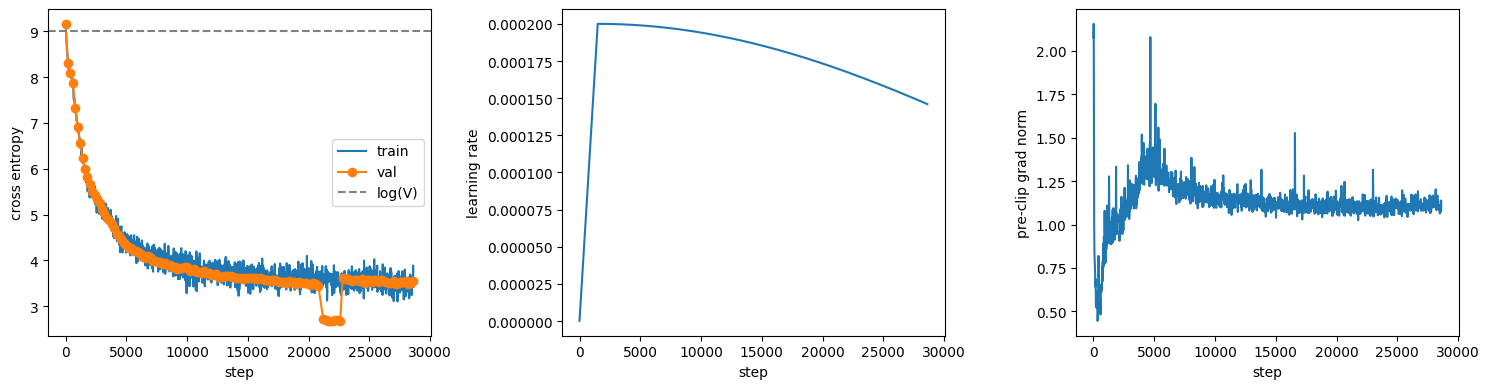

final train loss:     3.4185
final val loss:       3.5436
final val perplexity: 34.59


In [25]:
if tinyllm_30m_history is not None:
    plot_training_history(
        tinyllm_30m_history,
        baseline_loss=math.log(tinyllm_vocab_size),
    )

In [27]:
if tinyllm_30m_model is not None:
    show_model_samples(
        "TinyLLM 30M",
        tinyllm_30m_model,
        tinyllm_tokenizer,
        prompt="The most important idea in physics is",
        seed=0,
    )


TinyLLM 30M raw sample, escaped so control bytes do not wreck notebook output
------------------------------------------------------------------------
The most important idea in physics is: What's the big bang is is that you can't stop it?"\nKenneth Willy, a professor at Marren School of Medicine, and a professor at Cardiovascular Medicine, said: "Every time we've been talking about it there wouldn't be any evidence much less about the medical debates."\nKenneth Willy, a professor of physics at Cardiovascular Research Institute, has found a lot more to this issue, and researchers led the same project, "Trust A criminal justice system is just that that will affect society from what I think is relevant to challenges."\nWhich is why we do what you say about a psychologist internationally? Will we make true sense the way things are being valued in the future, in our society? Accorditcohort General, a criminal justice system is a procedure that is evolving, critical and not limited to the p

### Save TinyLLM 30M as `TinyLLM`

Run **only when the run looks done.** Publishes `artifacts/models/TinyLLM/` for the assistant-shaped tracks in Modules 13-15.


In [22]:
if tinyllm_30m_model is not None and tinyllm_30m_history is not None:
    save_model_artifact(
        "TinyLLM",
        model=tinyllm_30m_model,
        model_config=tinyllm_30m_model_config,
        training_config=tinyllm_30m_trainer_config,
        tokenizer_artifact_name=tinyllm_tokenizer_name,
        source=tinyllm_source_label,
        history=tinyllm_30m_history,
        seed=3,
        notes="Module 10 -- broader-corpus model on G2C corpus.",
        repo_root=repo_root,
    )
    print("saved TinyLLM")


saved TinyLLM


In [ ]:
"Question: How does the TinyStories 5M validation curve compare with the TinyShakespeare curve?"
"Answer: "

"Question: If you ran the 30M model, did validation keep improving longer or overfit sooner?"
"Answer: "

"Question: What changed more visibly in samples: spelling, sentence shape, or story coherence?"
"Answer: "

"Question: If you ran TinyLLM 30M, how do its samples differ from StoryLM 30M trained with the same architecture? Where does the broader corpus help, and where does it hurt at this scale?"
"Answer: "


When complete, ask a coding agent to grade your Module 10 notebook. Partial work is fine: the agent should grade answered questions and implemented sections, then skip blank prompts.